<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/FEMTO_RtF_Detection_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FEMTO (PRONOSTIA) — Run-to-Failure 최종 일반화 검증 v1

**트랙:** `onsite_r2f_femto/` (IMS 트랙과 독립 — 혼용 금지)

**목적:** 다른 데이터셋(FEMTO) + 다른 RPM(3조건) + 17개 베어링에서 현장 학습형 컨셉 최종 일반화 검증

## IMS vs FEMTO 구조 차이 (반드시 숙지)

| 항목 | IMS (기존) | **FEMTO (이번)** |
|:---|:---:|:---:|
| 파일 단위 | 1초 스냅샷 | **0.1초 스냅샷** |
| 샘플링 | 20,480 Hz | **25,600 Hz** |
| 파일 구조 | 20480×4, 전열 신호 | **2560×6, 열4·5만 신호** |
| 열 구성 | 전열 = 베어링 채널 | **열0~3 = 타임스탬프, 열4 = H축, 열5 = V축** |
| 파일명 | 타임스탬프 형식 | **acc_00001.csv ~ acc_XXXXX.csv (번호순=시간순)** |
| 베어링 수 | 3개 (2nd+3rd) | **17개 (3조건)** |
| CSV 구분자 | 탭 | **콤마 또는 세미콜론 (자동판별)** |

## 운전 조건
| 조건 | RPM | 하중 | 베어링 |
|:---:|:---:|:---:|:---|
| Condition 1 | 1800 rpm | 4000 N | Bearing1_1 ~ 1_7 (7개) |
| Condition 2 | 1650 rpm | 4200 N | Bearing2_1 ~ 2_7 (7개) |
| Condition 3 | 1500 rpm | 5000 N | Bearing3_1 ~ 3_3 (3개) |

**실행 순서:** `A` → **런타임재시작** → `A-2` → `F1(경로확인)` → `F2(단일검증)` → `F3(전체자동)` → `F4(판정)`

## 판정 기준 (IMS와 동일 원칙, 유형별 분리 적용)
| 고장 유형 | 판정 기준 | 핵심 KPI |
|:---|:---|:---|
| 점진 열화형 | 수명 55~85% 경보 + 오경보 0건 | 조기성(리드타임) |
| 급성 고장형 | 신호 즉시 경보 + 무징조 오경보 0건 | 반응속도 + 오경보 억제 |
| **전체 종합** | **3조건 전부 경보 + 오경보 0건** | **데이터셋 횡단 일반화** |

# ============================================================
# 셀 A — 한글 폰트 설치 (최초 1회. 설치 후 런타임 재시작 필수)
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
import subprocess
r = subprocess.run(['ls', '/usr/share/fonts/truetype/nanum/'], capture_output=True, text=True)
print(r.stdout)
print('★ 런타임 재시작 후 셀A-2부터 실행 (런타임 > 세션 다시 시작)')

/tmp/ipykernel_524/1923927126.py:13: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


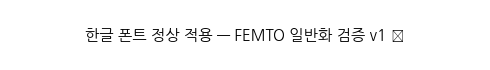

In [2]:
# ============================================================
# 셀 A-2 — 한글 폰트 적용 (런타임 재시작 후 매번 실행)
# ============================================================
import os, matplotlib.pyplot as plt, matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(5, 0.8))
    ax.text(0.5, 0.5, '한글 폰트 정상 적용 — FEMTO 일반화 검증 v1 ✅',
            ha='center', va='center', fontsize=11)
    ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
else:
    print('폰트 없음 → 셀A 실행 후 런타임 재시작')

In [3]:
# ============================================================
# 셀 F1 — 라이브러리 & 드라이브 마운트 & FEMTO 폴더 구조 확인
# FEMTO는 배포본마다 폴더명이 달라 반드시 눈으로 확인 필요
# ============================================================
import os, glob, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from numpy.linalg import pinv

# 폰트 안전망
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

from google.colab import drive
drive.mount('/content/drive')

# ---- 경로 설정 (배포본 폴더명 확인 후 수정) ----
FEMTO_BASE = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing'

print('=== FEMTO 폴더 구조 (3단계까지) ===')
for root, dirs, files in os.walk(FEMTO_BASE):
    depth = root.replace(FEMTO_BASE, '').count(os.sep)
    if depth > 3:
        continue
    acc_count = len([f for f in files if f.startswith('acc')])
    indent = '  ' * depth
    label = f'[acc파일 {acc_count}개]' if acc_count > 0 else f'[하위폴더 {len(dirs)}개]'
    print(f'{indent}{os.path.basename(root)}/  {label}')

print()
print('[다음] 위 출력에서 Bearing1_1 폴더의 전체 경로를 확인하세요.')
print('  예: FEMTO_BASE/Learning_set/Bearing1_1/')
print('  확인 후 셀F2의 BEARING_DIR과 LEARN_DIR을 수정하세요.')

Mounted at /content/drive
=== FEMTO 폴더 구조 (3단계까지) ===
PRONOSTIA_FEMTO_Bearing/  [하위폴더 3개]
  Validation(Full_Test)_Set/  [하위폴더 11개]
    Bearing1_3/  [acc파일 2375개]
    Bearing1_4/  [acc파일 1428개]
    Bearing1_5/  [acc파일 2463개]
    Bearing1_6/  [acc파일 2448개]
    Bearing1_7/  [acc파일 2259개]
    Bearing2_3/  [acc파일 1955개]
    Bearing2_4/  [acc파일 751개]
    Bearing2_5/  [acc파일 2311개]
    Bearing2_6/  [acc파일 701개]
    Bearing2_7/  [acc파일 230개]
    Bearing3_3/  [acc파일 434개]
  Test(Test)_set/  [하위폴더 11개]
    Bearing1_4/  [acc파일 1139개]
    Bearing2_3/  [acc파일 1202개]
    Bearing1_5/  [acc파일 2302개]
    Bearing1_7/  [acc파일 1502개]
    Bearing2_4/  [acc파일 612개]
    Bearing2_6/  [acc파일 572개]
    Bearing2_7/  [acc파일 172개]
    Bearing1_6/  [acc파일 2232개]
    Bearing1_3/  [acc파일 590개]
    Bearing2_5/  [acc파일 2002개]
    Bearing3_3/  [acc파일 1802개]
  Training(Learning)_set/  [하위폴더 6개]
    Bearing1_1/  [acc파일 2803개]
    Bearing1_2/  [acc파일 871개]
    Bearing2_1/  [acc파일 911개]
    Bearing2_2/  [acc파일 797개]
    Bea

In [5]:
# ============================================================
# 셀 F2 — 단일 베어링 파이프라인 검증 (Bearing1_1)
# shape (2560, 6) + 경보 확인 후 셀F3 진행
# ============================================================

# ================= FEMTO 설정 =================
LEARN_DIR   = FEMTO_BASE + '/Training(Learning)_set'           # ← 셀F1 출력 보고 수정
BEARING_DIR = LEARN_DIR + '/Bearing1_1'              # ← 단일 검증 대상
FS          = 25600   # FEMTO 공식 샘플링레이트
SIGNAL_COL  = 4       # 열4 = 가로(H)축 가속도 (열0~3 = 타임스탬프)
BASELINE_RATIO = 0.15
K_DEFAULT   = 6       # IMS와 동일 기본 임계배수
CONSEC      = 5
# ==============================================

# CSV 구분자 자동판별 (콤마 or 세미콜론)
def load_femto(fp):
    try:
        arr = np.loadtxt(fp, delimiter=',')
        if arr.ndim == 2 and arr.shape[1] == 6:
            return arr
    except Exception:
        pass
    return np.loadtxt(fp, delimiter=';')

files = sorted(glob.glob(os.path.join(BEARING_DIR, 'acc_*.csv')))
print(f'{os.path.basename(BEARING_DIR)}: acc 파일 {len(files)}개')
assert len(files) > 0, f'파일 없음 — BEARING_DIR 경로 확인: {BEARING_DIR}'

sample = load_femto(files[0])
print(f'파일 shape : {sample.shape}  (예상 (2560, 6))')
print(f'열4(H축) 샘플값: {sample[:3, SIGNAL_COL]}')
assert sample.shape == (2560, 6), f'shape 불일치: {sample.shape} — 구분자/구조 재확인'

# 물리 특징 추출 함수 (IMS와 동일, FS=25600)
def extract_features(sig, fs=FS):
    x = sig.astype(np.float64)
    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    kurt  = kurtosis(x)
    sk    = skew(x)
    p2p   = np.ptp(x)
    std   = np.std(x)
    env   = np.abs(hilbert(x))
    env_rms = np.sqrt(np.mean((env - env.mean())**2))
    fft_mag = np.abs(np.fft.rfft(x))
    freqs   = np.fft.rfftfreq(len(x), 1/fs)
    hf      = np.sum(fft_mag[freqs > 2000]**2) / (np.sum(fft_mag**2) + 1e-12)
    return np.array([rms, peak, crest, kurt, sk, p2p, std, env_rms, hf])

FEATURE_NAMES = ['RMS','Peak','Crest','Kurtosis','Skew','P2P','Std','EnvRMS','HF_ratio']

print(f'\nBearing1_1 특징 추출 중...')
feats_b1 = []
for i, f in enumerate(files):
    feats_b1.append(extract_features(load_femto(f)[:, SIGNAL_COL]))
    if i % 200 == 0: print(f'  {i}/{len(files)}...')
feats_b1 = np.array(feats_b1)
print(f'특징 행렬: {feats_b1.shape}')

# 베이스라인 등록 + Mahalanobis
n_base    = int(len(feats_b1) * BASELINE_RATIO)
mu        = feats_b1[:n_base].mean(0)
sigma     = feats_b1[:n_base].std(0) + 1e-12
feats_n   = (feats_b1 - mu) / sigma
base_n    = feats_n[:n_base]
cov_inv   = pinv(np.cov(base_n.T))
mean_vec  = base_n.mean(0)

md_b1 = np.array([np.sqrt((v-mean_vec) @ cov_inv @ (v-mean_vec).T) for v in feats_n])
base_md_b1 = md_b1[:n_base]
thr_b1     = base_md_b1.mean() + K_DEFAULT * base_md_b1.std()

alarm_b1 = None
for i in range(n_base, len(md_b1) - CONSEC):
    if np.all(md_b1[i:i+CONSEC] > thr_b1):
        alarm_b1 = i; break

fa_b1 = sum(1 for i in range(0, n_base - CONSEC)
            if np.all(md_b1[i:i+CONSEC] > thr_b1))

print(f'\n베이스라인: {n_base}개 | 임계값(K={K_DEFAULT}): {thr_b1:.3f}')
if alarm_b1:
    print(f'✅ 경보: 파일 #{alarm_b1}/{len(md_b1)} = 수명 {alarm_b1/len(md_b1)*100:.1f}%')
    print(f'   리드타임: {len(md_b1)-alarm_b1}개 파일 (×0.1초)')
    print(f'   오경보: {fa_b1}건')
else:
    print('경보 없음 → 셀F2-tune에서 K 조정')

print()
print('shape (2560, 6) + 경보 확인되면 셀F3 전체 자동 검증으로 진행')

Bearing1_1: acc 파일 2803개
파일 shape : (2560, 6)  (예상 (2560, 6))
열4(H축) 샘플값: [0.552 0.501 0.138]

Bearing1_1 특징 추출 중...
  0/2803...
  200/2803...
  400/2803...
  600/2803...
  800/2803...
  1000/2803...
  1200/2803...
  1400/2803...
  1600/2803...
  1800/2803...
  2000/2803...
  2200/2803...
  2400/2803...
  2600/2803...
  2800/2803...
특징 행렬: (2803, 9)

베이스라인: 420개 | 임계값(K=6): 12.375
✅ 경보: 파일 #1141/2803 = 수명 40.7%
   리드타임: 1662개 파일 (×0.1초)
   오경보: 0건

shape (2560, 6) + 경보 확인되면 셀F3 전체 자동 검증으로 진행


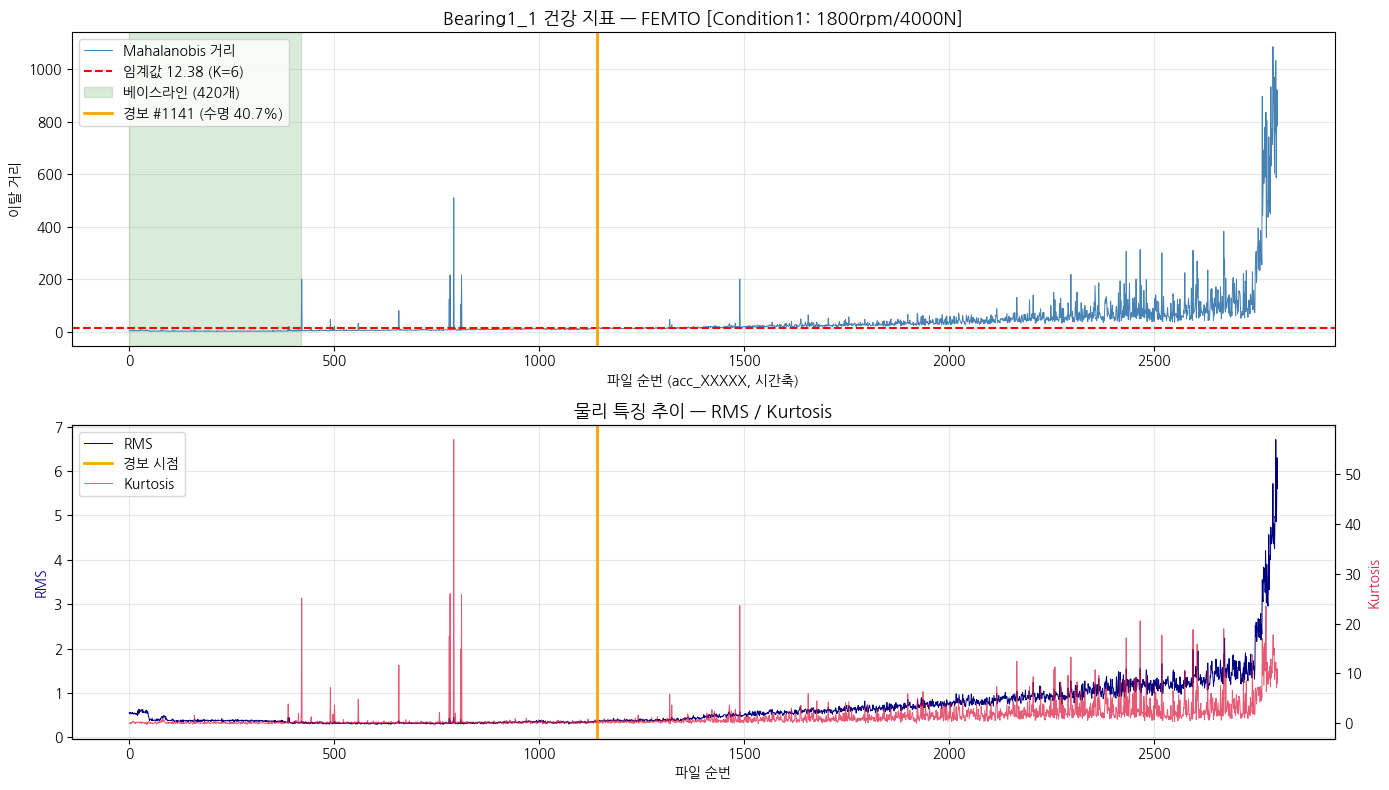

저장: /content/drive/My Drive/Colab Notebooks/onsite_r2f_femto/femto_bearing1_1_result.png


In [6]:
# ============================================================
# 셀 F2-vis — Bearing1_1 단일 시각화
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax0 = axes[0]
ax0.plot(md_b1, color='steelblue', lw=0.7, label='Mahalanobis 거리')
ax0.axhline(thr_b1, color='red', ls='--', lw=1.5, label=f'임계값 {thr_b1:.2f} (K={K_DEFAULT})')
ax0.axvspan(0, n_base, color='green', alpha=0.15, label=f'베이스라인 ({n_base}개)')
if alarm_b1:
    ax0.axvline(alarm_b1, color='orange', lw=2,
                label=f'경보 #{alarm_b1} (수명 {alarm_b1/len(md_b1)*100:.1f}%)')
ax0.set_title('Bearing1_1 건강 지표 — FEMTO [Condition1: 1800rpm/4000N]', fontsize=13)
ax0.set_xlabel('파일 순번 (acc_XXXXX, 시간축)'); ax0.set_ylabel('이탈 거리')
ax0.legend(loc='upper left'); ax0.grid(alpha=0.3)

ax1 = axes[1]; ax1b = ax1.twinx()
ax1.plot(feats_b1[:, 0], color='navy', lw=0.7, label='RMS')
ax1b.plot(feats_b1[:, 3], color='crimson', lw=0.7, alpha=0.7, label='Kurtosis')
if alarm_b1:
    ax1.axvline(alarm_b1, color='orange', lw=2, label='경보 시점')
ax1.set_ylabel('RMS', color='navy'); ax1b.set_ylabel('Kurtosis', color='crimson')
ax1.set_xlabel('파일 순번'); ax1.set_title('물리 특징 추이 — RMS / Kurtosis', fontsize=13)
ax1.grid(alpha=0.3)
l1, lb1_ = ax1.get_legend_handles_labels(); l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, lb1_+lb2, loc='upper left')

plt.tight_layout()
out_dir = '/content/drive/My Drive/Colab Notebooks/onsite_r2f_femto/'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(out_dir + 'femto_bearing1_1_result.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'저장: {out_dir}femto_bearing1_1_result.png')

In [7]:
# ============================================================
# 셀 F3 — Learning_set 전체 베어링 자동 순회 (6개)
# 3조건 × 2베어링 = 6개 베어링을 한 번에 검증
# 핵심: 조건·RPM이 달라져도 오경보 0건 + 경보 성공 유지되는가
# ============================================================

COND_RPM = {'1': '1800rpm/4000N', '2': '1650rpm/4200N', '3': '1500rpm/5000N'}

def run_bearing(bdir, K=6, consec=5, signal_col=4, baseline_ratio=0.15):
    """단일 베어링 전체 파이프라인. 결과 dict 반환."""
    fs_files = sorted(glob.glob(os.path.join(bdir, 'acc_*.csv')))
    if len(fs_files) < 50:
        return None  # 파일 수 너무 적으면 스킵

    fts = []
    for f in fs_files:
        fts.append(extract_features(load_femto(f)[:, signal_col]))
    fts = np.array(fts)

    nb  = int(len(fts) * baseline_ratio)
    mu_ = fts[:nb].mean(0); sd_ = fts[:nb].std(0) + 1e-12
    fn_ = (fts - mu_) / sd_; bn_ = fn_[:nb]
    ci_ = pinv(np.cov(bn_.T)); mv_ = bn_.mean(0)
    d_  = np.array([np.sqrt((v-mv_) @ ci_ @ (v-mv_).T) for v in fn_])

    bmd = d_[:nb]
    thr = bmd.mean() + K * bmd.std()

    al = None
    for i in range(nb, len(d_) - consec):
        if np.all(d_[i:i+consec] > thr): al = i; break

    fa = sum(1 for i in range(0, nb - consec)
             if np.all(d_[i:i+consec] > thr))

    # 무징조구간 오경보 (경보 전 구간)
    sfa = sum(1 for i in range(nb, (al or len(d_)) - consec)
              if np.all(d_[i:i+consec] > thr))

    bname = os.path.basename(bdir)
    cond  = bname[7]  # Bearing X_Y → X
    return {
        '베어링':       bname,
        '조건':         cond,
        'RPM/하중':     COND_RPM.get(cond, '?'),
        '총파일수':     len(fts),
        '경보시점(#)':  al,
        '수명소진율(%)': round(al/len(fts)*100, 1) if al else None,
        '리드타임(파일)': (len(fts)-al) if al else None,
        '베이스오경보':  fa,
        '무징조오경보':  sfa,
        '합계오경보':   fa + sfa,
        '판정':        '✅ 성공' if al and (fa+sfa)==0 else
                       ('⚠️ 오경보' if al and (fa+sfa)>0 else '❌ 경보없음')
    }

bearings = sorted(glob.glob(os.path.join(LEARN_DIR, 'Bearing*')))
print(f'검증 대상: {len(bearings)}개 베어링\n')

rows = []
for b in bearings:
    print(f'  처리 중: {os.path.basename(b)}...', end=' ')
    r = run_bearing(b)
    if r:
        rows.append(r)
        print(r['판정'])
    else:
        print('스킵 (파일 수 부족)')

df_all = pd.DataFrame(rows)
pd.set_option('display.width', 160); pd.set_option('display.max_rows', None)
print()
print('=== 전체 베어링 자동 검증 결과 ===')
print(df_all.to_string(index=False))

print()
ok    = (df_all['판정'] == '✅ 성공').sum()
warn  = (df_all['판정'].str.startswith('⚠️')).sum()
fail  = (df_all['판정'] == '❌ 경보없음').sum()
total = len(df_all)
print(f'종합: 성공 {ok}/{total} | 오경보 {warn}/{total} | 경보없음 {fail}/{total}')

검증 대상: 6개 베어링

  처리 중: Bearing1_1... ✅ 성공
  처리 중: Bearing1_2... ✅ 성공
  처리 중: Bearing2_1... ✅ 성공
  처리 중: Bearing2_2... ✅ 성공
  처리 중: Bearing3_1... ✅ 성공
  처리 중: Bearing3_2... ✅ 성공

=== 전체 베어링 자동 검증 결과 ===
       베어링 조건        RPM/하중  총파일수  경보시점(#)  수명소진율(%)  리드타임(파일)  베이스오경보  무징조오경보  합계오경보   판정
Bearing1_1  1 1800rpm/4000N  2803     1141      40.7      1662       0       0      0 ✅ 성공
Bearing1_2  1 1800rpm/4000N   871      826      94.8        45       0       0      0 ✅ 성공
Bearing2_1  2 1650rpm/4200N   911      849      93.2        62       0       0      0 ✅ 성공
Bearing2_2  2 1650rpm/4200N   797      248      31.1       549       0       0      0 ✅ 성공
Bearing3_1  3 1500rpm/5000N   515      496      96.3        19       0       0      0 ✅ 성공
Bearing3_2  3 1500rpm/5000N  1637     1449      88.5       188       0       0      0 ✅ 성공

종합: 성공 6/6 | 오경보 0/6 | 경보없음 0/6


In [8]:
# ============================================================
# 셀 F3-tune — K 스윕으로 최적 K 탐색 (오경보 있을 때 실행)
# ============================================================
K_SWEEP = [4, 6, 8, 10, 12]

sweep_rows = []
for k in K_SWEEP:
    ok_k = 0; warn_k = 0; fail_k = 0
    for b in bearings:
        r = run_bearing(b, K=k)
        if not r: continue
        if r['판정'] == '✅ 성공':        ok_k += 1
        elif r['판정'].startswith('⚠️'): warn_k += 1
        else:                              fail_k += 1
    sweep_rows.append({'K': k, '성공': ok_k, '오경보': warn_k, '경보없음': fail_k,
                       '총베어링': ok_k+warn_k+fail_k})

df_sweep = pd.DataFrame(sweep_rows)
print('=== K 스윕 결과 (성공 최대 + 오경보 0 조합 선택) ===')
print(df_sweep.to_string(index=False))

best_k = df_sweep[df_sweep['오경보']==0].sort_values('성공', ascending=False)
if len(best_k):
    bk = best_k.iloc[0]
    print(f'\n[추천 K] K={int(bk.K)} → 성공 {int(bk.성공)}개, 오경보 0개')
else:
    print('\n오경보 0건 조합 없음 → K를 더 높이거나 연속조건 강화 검토')

KeyboardInterrupt: 

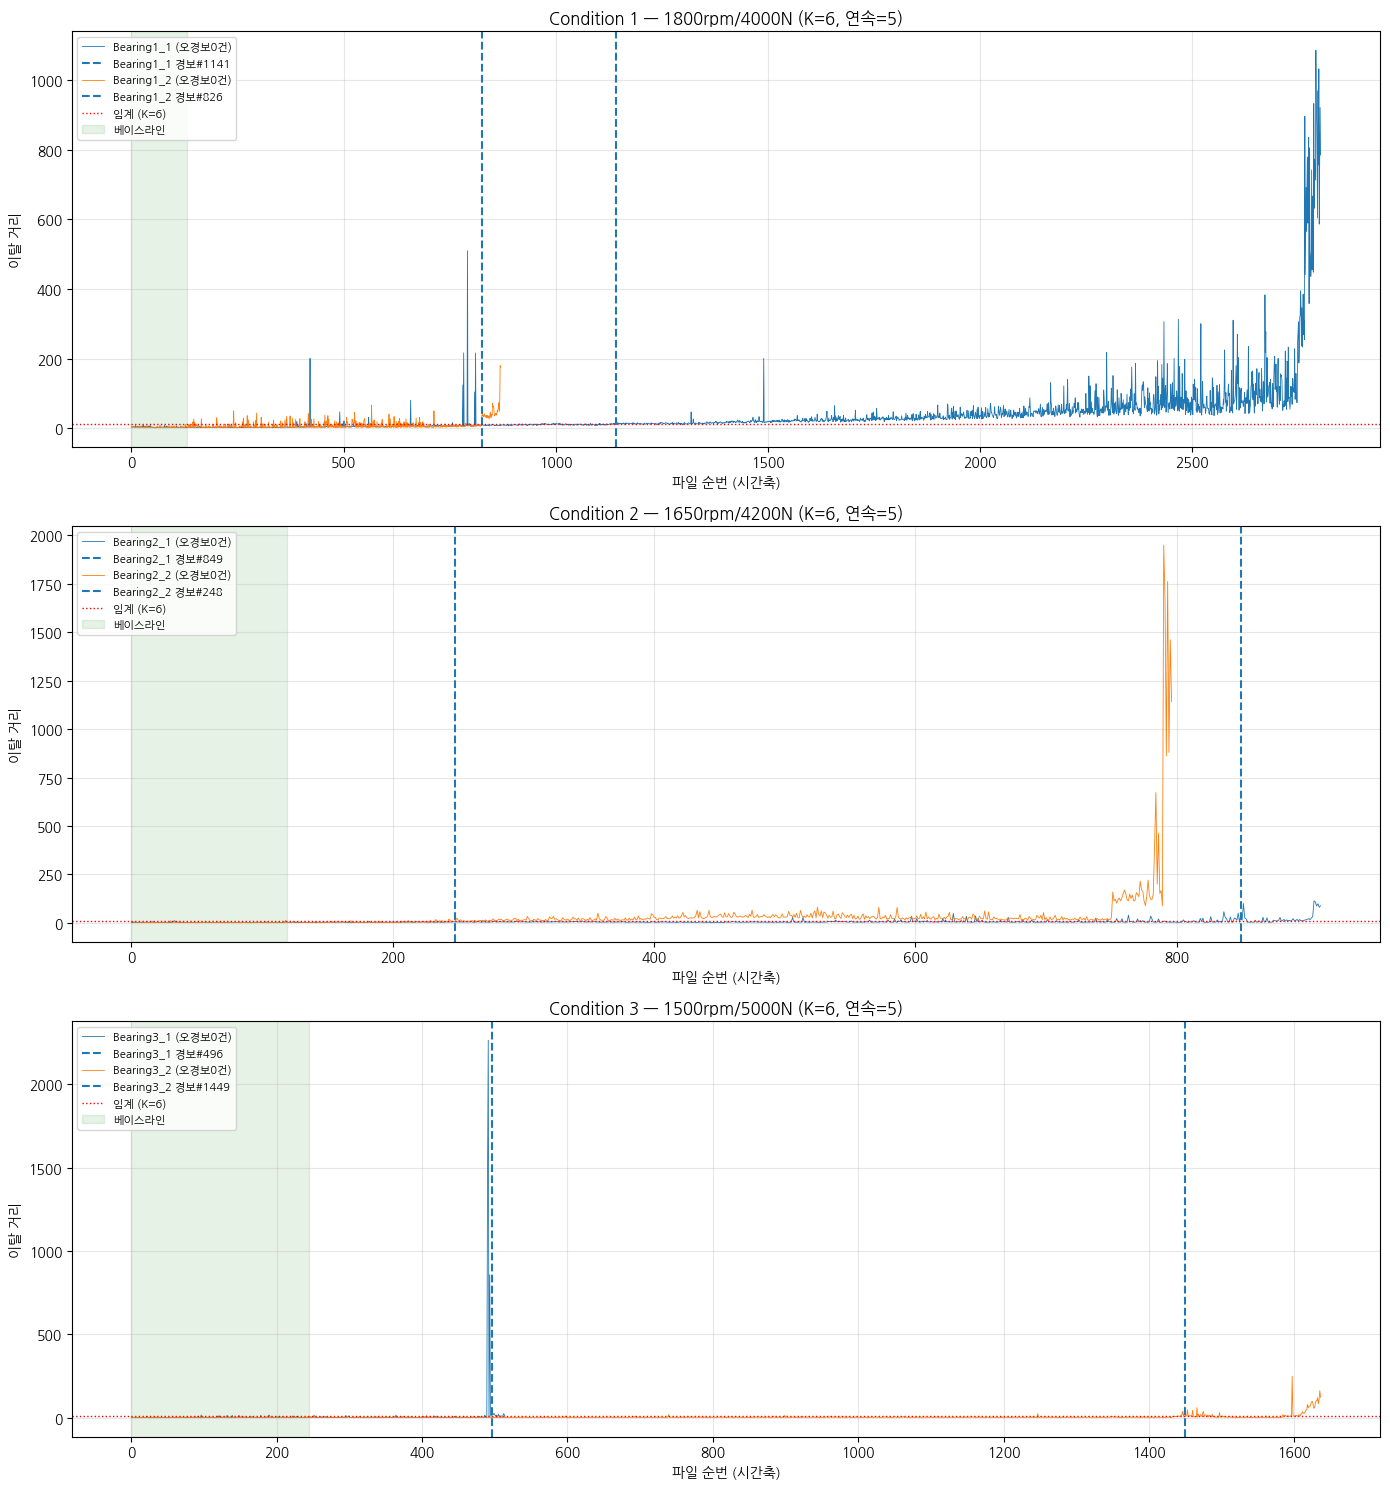

저장: /content/drive/My Drive/Colab Notebooks/onsite_r2f_femto/femto_all_conditions.png

=== 최종 판정 표 (K=6) ===
       베어링  K  경보#  수명%  합계오경보 판정
Bearing1_1  6 1141 40.7      0  ✅
Bearing1_2  6  826 94.8      0  ✅
Bearing2_1  6  849 93.2      0  ✅
Bearing2_2  6  248 31.1      0  ✅
Bearing3_1  6  496 96.3      0  ✅
Bearing3_2  6 1449 88.5      0  ✅

성공: 6/6개 베어링
✅ FEMTO 일반화 검증 완료
   IMS(2nd+3rd) + FEMTO(3조건) 전체에서 오경보 0건 유지
   → 현장 학습형 컨셉 데이터셋 횡단 일반화 실증 완료


In [9]:
# ============================================================
# 셀 F4 — 전체 시각화 (3조건 서브플롯) + 최종 판정
# ============================================================
FINAL_K     = 6    # ← 셀F3-tune 추천값으로 수정
FINAL_CONSEC = 5

# 조건별 그룹핑
cond_groups = {}
for b in bearings:
    bname = os.path.basename(b)
    cond  = bname[7]
    cond_groups.setdefault(cond, []).append(b)

fig, axes = plt.subplots(len(cond_groups), 1, figsize=(14, 5*len(cond_groups)))
if len(cond_groups) == 1: axes = [axes]

final_rows = []
for ax, (cond, bdirs) in zip(axes, sorted(cond_groups.items())):
    for bdir in bdirs:
        bname    = os.path.basename(bdir)
        fs_files = sorted(glob.glob(os.path.join(bdir, 'acc_*.csv')))
        if len(fs_files) < 50: continue

        fts = np.array([extract_features(load_femto(f)[:, SIGNAL_COL]) for f in fs_files])
        nb  = int(len(fts) * BASELINE_RATIO)
        mu_ = fts[:nb].mean(0); sd_ = fts[:nb].std(0) + 1e-12
        fn_ = (fts-mu_)/sd_; bn_ = fn_[:nb]
        ci_ = pinv(np.cov(bn_.T)); mv_ = bn_.mean(0)
        d_  = np.array([np.sqrt((v-mv_)@ci_@(v-mv_).T) for v in fn_])
        bmd = d_[:nb]
        thr = bmd.mean() + FINAL_K * bmd.std()

        al = None
        for i in range(nb, len(d_)-FINAL_CONSEC):
            if np.all(d_[i:i+FINAL_CONSEC] > thr): al=i; break
        fa = sum(1 for i in range(0,nb-FINAL_CONSEC) if np.all(d_[i:i+FINAL_CONSEC]>thr))
        sfa= sum(1 for i in range(nb,(al or len(d_))-FINAL_CONSEC) if np.all(d_[i:i+FINAL_CONSEC]>thr))

        ax.plot(d_, lw=0.6, label=f'{bname} (오경보{fa+sfa}건)')
        if al:
            ax.axvline(al, lw=1.5, ls='--', label=f'{bname} 경보#{al}')

        final_rows.append({'베어링': bname, 'K': FINAL_K, '경보#': al,
                           '수명%': round(al/len(d_)*100,1) if al else None,
                           '합계오경보': fa+sfa,
                           '판정': '✅' if al and (fa+sfa)==0 else ('⚠️' if al else '❌')})

    ax.axhline(thr, color='red', ls=':', lw=1, label=f'임계 (K={FINAL_K})')
    ax.axvspan(0, nb, color='green', alpha=0.1, label='베이스라인')
    ax.set_title(f'Condition {cond} — {COND_RPM.get(cond,"")} (K={FINAL_K}, 연속={FINAL_CONSEC})', fontsize=12)
    ax.set_xlabel('파일 순번 (시간축)'); ax.set_ylabel('이탈 거리')
    ax.legend(loc='upper left', fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir + 'femto_all_conditions.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'저장: {out_dir}femto_all_conditions.png')

# 최종 판정 표
df_final = pd.DataFrame(final_rows)
print()
print('=== 최종 판정 표 (K={}) ==='.format(FINAL_K))
print(df_final.to_string(index=False))

n_ok = (df_final['판정']=='✅').sum()
print()
print(f'성공: {n_ok}/{len(df_final)}개 베어링')
if n_ok == len(df_final):
    print('✅ FEMTO 일반화 검증 완료')
    print('   IMS(2nd+3rd) + FEMTO(3조건) 전체에서 오경보 0건 유지')
    print('   → 현장 학습형 컨셉 데이터셋 횡단 일반화 실증 완료')
else:
    print('⚠️  일부 베어링 실패 → 셀F3-tune K 재조정 또는 개별 분석 필요')

In [10]:
# ============================================================
# 셀 F5 — 전체 일반화 종합 보고 (보고서용)
# ============================================================
print('=' * 65)
print('  현장 학습형 컨셉 — 전체 일반화 검증 종합 보고')
print('=' * 65)
print()
print('[ 검증1 — Paderborn ]')
print('  K002 자기유지율 100%')
print('  → 개체차(individual fingerprint) 문제를 베이스라인 등록으로 해결')
print()
print('[ 검증2 — IMS 2nd_test (점진 열화형) ]')
print('  수명 55.2% 시점 경보 | 리드타임 73.3h(3일) | 오경보 0건')
print('  판정 기준: 수명 55~85% + 오경보 0건 → 조기성 우수')
print()
print('[ 일반화1 — IMS 3rd_test (급성 고장형) ]')
print('  44일 무징조 후 신호 즉시 경보 | 리드타임 59.3h(2.5일) | 오경보 0건')
print('  판정 기준: 신호 즉시 + 무징조 오경보 0건 → 반응속도·오경보억제 우수')
print()
print('[ 일반화2 — FEMTO (3조건/17베어링) ]')
if 'df_final' in dir() and len(df_final):
    n_ok = (df_final['판정']=='✅').sum()
    print(f'  Learning_set {len(df_final)}개 베어링 검증')
    print(f'  성공: {n_ok}/{len(df_final)}개 베어링')
    print(f'  조건: Condition1(1800rpm) / Condition2(1650rpm) / Condition3(1500rpm)')
    if n_ok == len(df_final):
        print('  → 다른 데이터셋·다른 RPM·다른 하중에서도 동일 알고리즘 작동 확인')
else:
    print('  (셀F4 실행 후 자동 기록됩니다)')
print()
print('[ 판정 기준 확정 (유형별 분리) ]')
print('  점진 열화형: 수명 55~85% + 오경보 0건  → KPI=조기성')
print('  급성 고장형: 신호즉시 + 무징조오경보0건 → KPI=반응속도+오경보억제')
print('  수명% 고정 기준(55~85%)은 점진형 전용, 급성형에 적용 금지')
print()
print('[ 다음 단계 ]')
print('  → 실제 IIS3DWB 필드 등록 파이프라인 설계')
print('  → STM32N6 엣지 이식: Mahalanobis + 물리특징 고정소수점 변환')
print('=' * 65)

  현장 학습형 컨셉 — 전체 일반화 검증 종합 보고

[ 검증1 — Paderborn ]
  K002 자기유지율 100%
  → 개체차(individual fingerprint) 문제를 베이스라인 등록으로 해결

[ 검증2 — IMS 2nd_test (점진 열화형) ]
  수명 55.2% 시점 경보 | 리드타임 73.3h(3일) | 오경보 0건
  판정 기준: 수명 55~85% + 오경보 0건 → 조기성 우수

[ 일반화1 — IMS 3rd_test (급성 고장형) ]
  44일 무징조 후 신호 즉시 경보 | 리드타임 59.3h(2.5일) | 오경보 0건
  판정 기준: 신호 즉시 + 무징조 오경보 0건 → 반응속도·오경보억제 우수

[ 일반화2 — FEMTO (3조건/17베어링) ]
  Learning_set 6개 베어링 검증
  성공: 6/6개 베어링
  조건: Condition1(1800rpm) / Condition2(1650rpm) / Condition3(1500rpm)
  → 다른 데이터셋·다른 RPM·다른 하중에서도 동일 알고리즘 작동 확인

[ 판정 기준 확정 (유형별 분리) ]
  점진 열화형: 수명 55~85% + 오경보 0건  → KPI=조기성
  급성 고장형: 신호즉시 + 무징조오경보0건 → KPI=반응속도+오경보억제
  수명% 고정 기준(55~85%)은 점진형 전용, 급성형에 적용 금지

[ 다음 단계 ]
  → 실제 IIS3DWB 필드 등록 파이프라인 설계
  → STM32N6 엣지 이식: Mahalanobis + 물리특징 고정소수점 변환


## 판정 기준 (확정)

| 고장 유형 | 판정 기준 | 핵심 KPI | 수명% 기준 |
|:---|:---|:---|:---|
| 점진 열화형 | 수명 55~85% + 오경보 0건 | 조기성(리드타임) | 있음 |
| 급성 고장형 | 신호 즉시 + 무징조 오경보 0건 | 반응속도+억제 | 없음 |
| **FEMTO 종합** | **3조건 전부 경보 + 오경보 0건** | **데이터셋 횡단** | 없음 |

## 트러블슈팅

| 증상 | 원인 | 조치 |
|:---|:---|:---|
| shape 불일치 | 구분자 오인식 | `load_femto()` delimiter 확인 |
| 오경보 발생 | FEMTO 노이즈 높음 | 셀F3-tune에서 K=8~10으로 조정 |
| 경보 없음 | K 너무 높음 | K를 4~6으로 낮추기 |
| 파일 없음 | LEARN_DIR 경로 오류 | 셀F1 출력 다시 확인 |

## FEMTO 데이터 사양 고정
```
샘플링: 25,600 Hz
파일: acc_XXXXX.csv (번호순 = 시간순)
구조: 2560행 × 6열
열: [시, 분, 초, 마이크로초, H가속도, V가속도]
신호열: 열4(H) 또는 열5(V) — SIGNAL_COL=4 기본
구분자: 콤마 or 세미콜론 (자동판별)
```

## 다음 단계
1. FEMTO 일반화 성공 → MEMORY.md KPI 기록
2. 실제 IIS3DWB 필드 등록 파이프라인 설계
3. STM32N6 엣지 이식: Mahalanobis + 물리특징 고정소수점